In [1]:
!pip install pandas_ta
!pip install ta
!pip install mplfinance

  Using cached ta-0.11.0.tar.gz (25 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=edb56173902ef76cf2e740a8721dd063983e8125c324ab496a9663e3b784bc66
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.5 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import mplfinance as mpf
import numpy as np

[*********************100%***********************]  1 of 1 completed


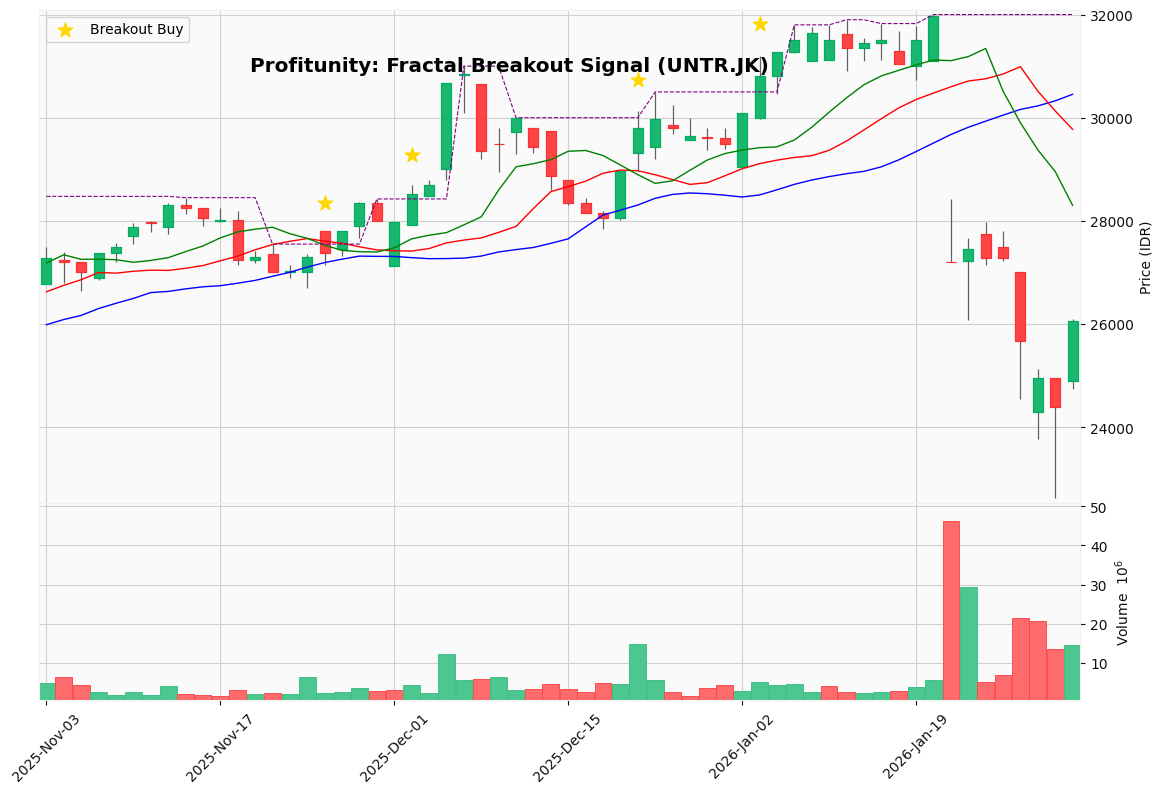

In [9]:
# 1. Fetch Data (Fetch 6mo to calculate indicators, we will view last 3mo)
ticker = "UNTR.JK"
data = yf.download(ticker, period="6mo", interval="1d", auto_adjust=True)

# Flatten MultiIndex columns (Fix for yfinance v0.2+)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] for col in data.columns]

if data.empty:
    print(f"No data found for {ticker}.")
else:
    # 2. Calculate Alligator
    # Jaw (Blue, Slow)
    data['Jaw'] = ta.smma(data['Close'], length=13).shift(8)
    # Teeth (Red, Medium)
    data['Teeth'] = ta.smma(data['Close'], length=8).shift(5)
    # Lips (Green, Fast)
    data['Lips'] = ta.smma(data['Close'], length=5).shift(3)

    # 3. Define Fractals (Using 3-bar logic for sensitivity)
    # A fractal is defined when High[t] is higher than neighbors
    data['Fractal_High'] = (data['High'] > data['High'].shift(1)) & (data['High'] > data['High'].shift(-1))

    # --- LOGIC FIX START ---

    # Step A: Filter for "Valid" Buy Fractals
    # Bill Williams Rule: A Buy Fractal is only valid if it forms ABOVE the Red Line (Teeth).
    data['Valid_Fractal_Level'] = data.apply(
        lambda x: x['High'] if (x['Fractal_High'] and x['High'] > x['Teeth']) else np.nan,
        axis=1
    )

    # Step B: Carry this level forward (The "Resistance Line")
    # We forward fill the valid fractal level so we know what price needs to be broken
    data['Resistance_Line'] = data['Valid_Fractal_Level'].ffill()

    # Step C: The REAL Buy Signal (Breakout)
    # Buy when Price CROSSES the Resistance Line
    # We use shift(1) for resistance to ensure we are breaking a PREVIOUS fractal, not forming a new one.
    buy_condition = (
        (data['High'] > data['Resistance_Line'].shift(1)) &     # Price breaks the level
        (data['High'].shift(1) <= data['Resistance_Line'].shift(1)) # It wasn't already broken yesterday
    )

    data['Buy_Signal'] = data.apply(lambda x: x['High'] * 1.02 if buy_condition.loc[x.name] else np.nan, axis=1)

    # --- LOGIC FIX END ---

    # Slice data for better visibility (Last 60 candles)
    recent_data = data.tail(60).copy()

    # --- VISUALIZATION ---
    apds = [
        # Alligator
        mpf.make_addplot(recent_data['Jaw'], color='blue', width=1.0),
        mpf.make_addplot(recent_data['Teeth'], color='red', width=1.0),
        mpf.make_addplot(recent_data['Lips'], color='green', width=1.0),

        # The "Trigger Line" (Dotted Purple line showing the level to break)
        mpf.make_addplot(recent_data['Resistance_Line'], color='purple', linestyle='--', width=0.8),

        # The Buy Signal (Gold Star)
        mpf.make_addplot(recent_data['Buy_Signal'], type='scatter', markersize=120, marker='*', color='gold', label='Breakout Buy')
    ]

    s = mpf.make_mpf_style(base_mpf_style='yahoo', rc={'font.size': 10})

    mpf.plot(
        recent_data,
        type='candle',
        style=s,
        addplot=apds,
        title=f"\nProfitunity: Fractal Breakout Signal ({ticker})",
        ylabel='Price (IDR)',
        volume=True,
        figsize=(12, 8),
        tight_layout=True
    )